# CONUS maps of the zeta-gradient reachability field

Task 9 of the zeta-sensitivity plan: spatial maps of the adjoint reachability probe
`d(L1)/d(normalized leakance params)` over the eval network.

- **Probe checkpoint (trained)**: `.ddrs/runs/2026-07-01T13-43-32Z-train-and-test/checkpoints/epoch_5_mb_9` (from `grad_trained.nc` attr `probe_checkpoint`)
- **Cold probe**: `grad_cold.nc` (untrained/cold-init head, same probe plan; checkpoint attr printed below)
- **Inputs**:
  - `/home/tbindas/projects/ddrs/output/zeta_probe/grad_trained.nc`, `grad_cold.nc` — dim `COMID_probe` (64,892 = full eval network), vars `grad_factor_{abs,net}`, `grad_dgw_{abs,net}`, `grad_kd_{abs,net}`, `n_windows`
  - `/home/tbindas/projects/ddr/references/gage_info/gages_3000.csv` — gauge LAT/LNG + COMID
  - `/home/tbindas/projects/ddr/data/merit_gages_conus_adjacency.zarr` — per-gauge subgraph membership (`<STAID>/order`)
  - `/home/tbindas/projects/ddr/data/merit/riv_pfaf_7_MERIT_Hydro_v07_Basins_v01_bugfix1.shp` — MERIT CONUS flowlines for the per-reach map
- **Figures**:
  1. `gradient_gauge_map.png` — per-gauge 4-panel scatter: trained/cold x (log10 median |dL/dfactor|, sign fraction of `grad_factor_net > 0`)
  2. `gradient_reach_map.png` — per-reach flowline map of trained `log10(grad_factor_abs)`
- **Interpretation key**: sign fraction > 0.5 = loss pushes leakance DOWN in this basin.
- **Generated**: 2026-07-02


In [1]:
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from mpl_toolkits.axes_grid1 import make_axes_locatable

PROBE_DIR = Path("/home/tbindas/projects/ddrs/output/zeta_probe")
PLOT_DIR = PROBE_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

GRAD_TRAINED_NC = PROBE_DIR / "grad_trained.nc"
GRAD_COLD_NC = PROBE_DIR / "grad_cold.nc"
GAGES_CSV = Path("/home/tbindas/projects/ddr/references/gage_info/gages_3000.csv")
GAGES_ZARR = Path("/home/tbindas/projects/ddr/data/merit_gages_conus_adjacency.zarr")
RIV_SHP = Path(
    "/home/tbindas/projects/ddr/data/merit/riv_pfaf_7_MERIT_Hydro_v07_Basins_v01_bugfix1.shp"
)

XLIM, YLIM = (-125, -66), (24, 53)  # CONUS, EPSG:4326
SAVE_KW = dict(dpi=300, bbox_inches="tight", facecolor="white")


def add_positron(ax, crs):
    """CartoDB.Positron basemap per skill conventions; degrade gracefully offline."""
    try:
        cx.add_basemap(
            ax, crs=crs, source=cx.providers.CartoDB.Positron,
            alpha=0.6, zorder=0, attribution=False,
        )
    except Exception as e:
        print(f"basemap skipped ({type(e).__name__}: {e})")
        ax.set_facecolor("#f0f0f0")


def log10_safe(v):
    v = np.asarray(v, dtype=float)
    out = np.full_like(v, np.nan)
    m = np.isfinite(v) & (v > 0)
    out[m] = np.log10(v[m])
    return out


In [2]:
# --- Load the gradient probes -------------------------------------------
ds_tr = xr.open_dataset(GRAD_TRAINED_NC)
ds_co = xr.open_dataset(GRAD_COLD_NC)
print("trained probe_checkpoint:", ds_tr.attrs.get("probe_checkpoint"))
print("cold    probe_checkpoint:", ds_co.attrs.get("probe_checkpoint"))
print("trained probe_note:      ", ds_tr.attrs.get("probe_note"))

comids = ds_tr["COMID_probe"].values
assert np.array_equal(comids, ds_co["COMID_probe"].values), "probe COMID axes differ"
comid_idx = pd.Index(comids)
assert comid_idx.is_unique

tr_abs = ds_tr["grad_factor_abs"].values.astype(np.float64)
tr_net = ds_tr["grad_factor_net"].values.astype(np.float64)
co_abs = ds_co["grad_factor_abs"].values.astype(np.float64)
co_net = ds_co["grad_factor_net"].values.astype(np.float64)
print(f"{len(comids):,} probe reaches (full eval network)")
print(f"trained |g| median {np.median(tr_abs):.3e}, cold |g| median {np.median(co_abs):.3e}")


trained probe_checkpoint: .ddrs/runs/2026-07-01T13-43-32Z-train-and-test/checkpoints/epoch_5_mb_9
cold    probe_checkpoint: cold-init-seed42
trained probe_note:       adjoint reachability: d(L1)/d(normalized leakance params), mean over covering windows
64,892 probe reaches (full eval network)
trained |g| median 4.036e-05, cold |g| median 1.398e-04


In [3]:
# --- Match gauges to per-gauge subgraphs, aggregate over subgraph COMIDs -
gages = pd.read_csv(GAGES_CSV, dtype={"STAID": str})
gages["STAID"] = gages["STAID"].str.zfill(8)

root = zarr.open_group(str(GAGES_ZARR), mode="r")
zarr_groups = set(root.keys())
matched = sorted(set(gages["STAID"]) & zarr_groups)
print(
    f"matched {len(matched)} gauges "
    f"(gages_3000: {len(gages)}, zarr groups: {len(zarr_groups)})"
)
gages_m = gages.drop_duplicates("STAID").set_index("STAID").loc[matched]

rows = []
n_missing_reaches = 0
for staid in matched:
    order = np.asarray(root[staid]["order"][:], dtype=np.int64)
    pos = comid_idx.get_indexer(order)
    n_missing_reaches += int((pos < 0).sum())
    pos = pos[pos >= 0]
    if pos.size == 0:
        continue
    rows.append({
        "STAID": staid,
        "n_reach": pos.size,
        "tr_med_abs": float(np.median(tr_abs[pos])),
        "tr_sign_frac": float(np.mean(tr_net[pos] > 0)),
        "co_med_abs": float(np.median(co_abs[pos])),
        "co_sign_frac": float(np.mean(co_net[pos] > 0)),
    })
agg = pd.DataFrame(rows).set_index("STAID").join(
    gages_m[["LAT_GAGE", "LNG_GAGE", "DRAIN_SQKM"]]
)
print(f"{len(agg)} gauges aggregated; subgraph members missing from probe: {n_missing_reaches}")
agg["tr_log10"] = log10_safe(agg["tr_med_abs"])
agg["co_log10"] = log10_safe(agg["co_med_abs"])
agg[["n_reach", "tr_log10", "tr_sign_frac", "co_log10", "co_sign_frac"]].describe()


matched 3211 gauges (gages_3000: 3211, zarr groups: 8945)


2918 gauges aggregated; subgraph members missing from probe: 27416


,n_reach,tr_log10,tr_sign_frac,co_log10,co_sign_frac
count,2918.000000,2911.000000,2918.000000,2910.000000,2918.000000
mean,56.799863,-4.406200,0.479622,-3.812165,0.774510
std,110.354729,0.453745,0.308243,0.788836,0.345189
min,1.000000,-7.098026,0.000000,-12.708051,0.000000
25%,5.000000,-4.634708,0.243054,-4.180267,0.666667
50%,17.000000,-4.393290,0.491978,-3.683887,0.975610
75%,53.000000,-4.150607,0.692308,-3.322901,1.000000
max,978.000000,-2.032824,1.000000,-1.604386,1.000000


## Figure 1 — per-gauge scatter (4 panels)

Per gauge: median over its subgraph COMIDs of |dL/dfactor| (log10, viridis) and the
fraction of subgraph reaches with `grad_factor_net > 0` (coolwarm centered at 0.5).
Top row = trained probe, bottom row = cold probe. Columns share color scales.

saved /home/tbindas/projects/ddrs/output/zeta_probe/plots/gradient_gauge_map.png


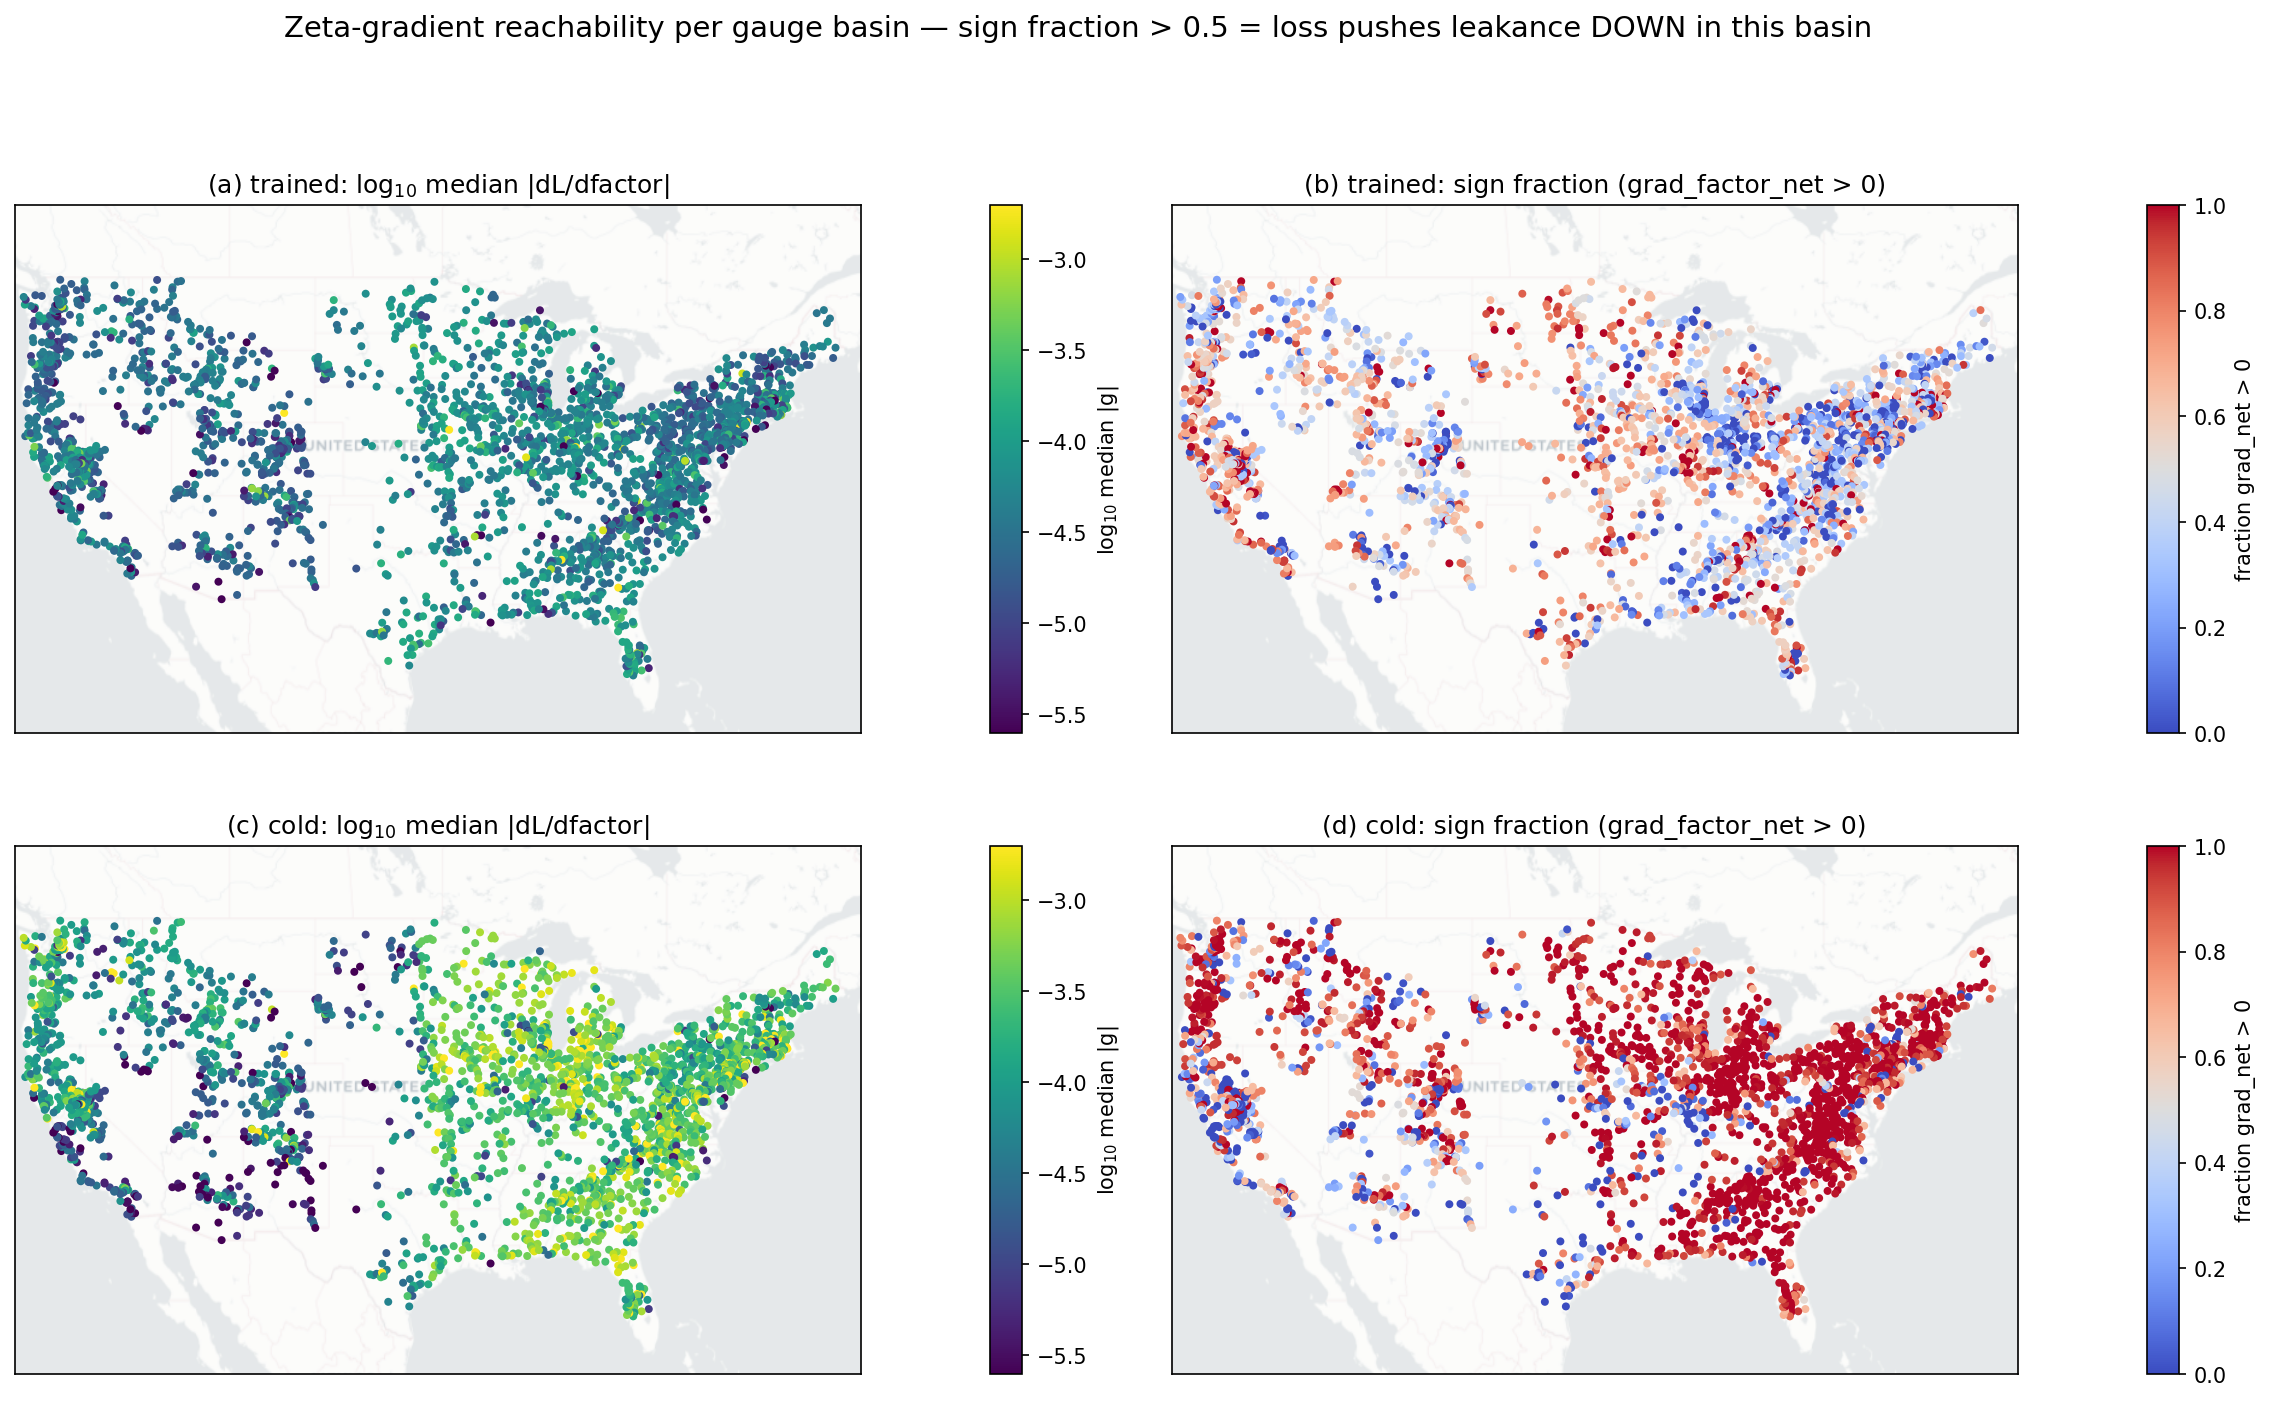

In [4]:
gdf_g = gpd.GeoDataFrame(
    agg,
    geometry=gpd.points_from_xy(agg["LNG_GAGE"], agg["LAT_GAGE"]),
    crs="EPSG:4326",
)

both_log = np.concatenate([
    agg["tr_log10"].dropna().values, agg["co_log10"].dropna().values,
])
vmin_l, vmax_l = np.nanpercentile(both_log, [2, 98])

panels = [
    ("tr_log10", "(a) trained: log$_{10}$ median |dL/dfactor|", "viridis", vmin_l, vmax_l),
    ("tr_sign_frac", "(b) trained: sign fraction (grad_factor_net > 0)", "coolwarm", 0.0, 1.0),
    ("co_log10", "(c) cold: log$_{10}$ median |dL/dfactor|", "viridis", vmin_l, vmax_l),
    ("co_sign_frac", "(d) cold: sign fraction (grad_factor_net > 0)", "coolwarm", 0.0, 1.0),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=150)
for ax, (col, title, cmap, vmin, vmax) in zip(axes.flat, panels):
    sub = gdf_g.dropna(subset=[col])
    sub.plot(ax=ax, column=col, cmap=cmap, markersize=8, vmin=vmin, vmax=vmax, zorder=1)
    add_positron(ax, gdf_g.crs)
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=12)
    cax = make_axes_locatable(ax).append_axes("right", size="3%", pad=0.1)
    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_array([])
    sm.set_clim(vmin, vmax)
    label = "log$_{10}$ median |g|" if "log10" in col else "fraction grad_net > 0"
    fig.colorbar(sm, cax=cax).set_label(label)

fig.suptitle(
    "Zeta-gradient reachability per gauge basin — "
    "sign fraction > 0.5 = loss pushes leakance DOWN in this basin",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
out1 = PLOT_DIR / "gradient_gauge_map.png"
fig.savefig(out1, **SAVE_KW)
print(f"saved {out1}")


## Figure 2 — per-reach flowline map

Trained `log10(grad_factor_abs)` joined onto MERIT CONUS flowlines
(`riv_pfaf_7`, EPSG:4326), thin linewidth per the parameter_map reference
(flowlines are lines, not catchment polygons). Only the 64,892 eval-network
reaches carry values; the rest of the fabric is dropped before plotting.

joined 63,782 eval-network reaches of 346,327 fabric flowlines


saved /home/tbindas/projects/ddrs/output/zeta_probe/plots/gradient_reach_map.png


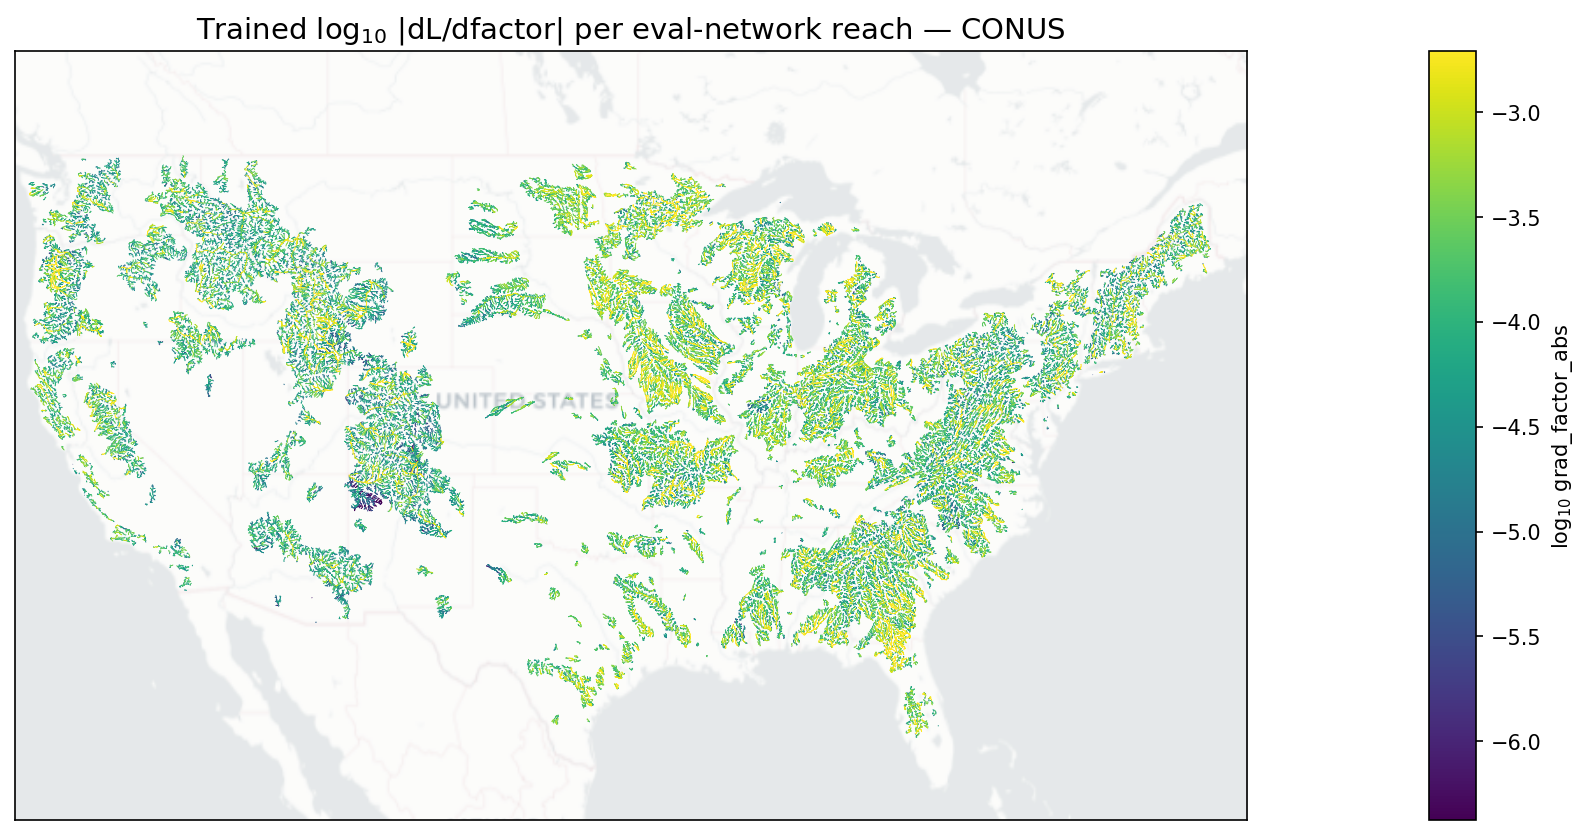

In [5]:
gdf_r = gpd.read_file(RIV_SHP, columns=["COMID"]).set_index("COMID")
if gdf_r.crs is None:
    gdf_r = gdf_r.set_crs(epsg=4326)
gdf_r["log10_grad"] = (
    pd.Series(log10_safe(tr_abs), index=comids).reindex(gdf_r.index).values
)
gdf_sub = gdf_r.dropna(subset=["log10_grad"]).sort_values("log10_grad")
print(f"joined {len(gdf_sub):,} eval-network reaches of {len(gdf_r):,} fabric flowlines")

vmin2, vmax2 = np.nanpercentile(gdf_sub["log10_grad"].values, [2, 98])
fig, ax = plt.subplots(figsize=(14, 8), dpi=150)
gdf_sub.plot(
    ax=ax, column="log10_grad", cmap="viridis",
    linewidth=0.4, vmin=vmin2, vmax=vmax2, zorder=1,
)
add_positron(ax, gdf_sub.crs)
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(
    "Trained log$_{10}$ |dL/dfactor| per eval-network reach — CONUS",
    fontsize=14,
)
cax = make_axes_locatable(ax).append_axes("right", size="3%", pad=0.1)
sm = plt.cm.ScalarMappable(cmap="viridis")
sm.set_array([])
sm.set_clim(vmin2, vmax2)
fig.colorbar(sm, cax=cax).set_label("log$_{10}$ grad_factor_abs")

out2 = PLOT_DIR / "gradient_reach_map.png"
fig.savefig(out2, **SAVE_KW)
print(f"saved {out2}")
